In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sqlite3
import random
import string

pd.read_csv("/Users/danilocastillo/Desktop/EDA_Jorge_Martinez_Kelly_Escalante_Danilo_Castillo/Data_sets/Licencias_2024y2025_limpio.csv")
pd.read_csv("/Users/danilocastillo/Desktop/EDA_Jorge_Martinez_Kelly_Escalante_Danilo_Castillo/Data_sets/siniestros_limpio.csv")


,nif,fechaparteaccidente,fechaaltaparte,codigo,actividad,lugar,fecharecepcion,entrenamiento,actividadpersonal,actividadorganizada,festivo,nresponsables,tamañogrupo,descripciongrado,pais,provincia,tipoaccidente
0,05277296S,2024-01-01 00:00:00,2024-01-02 12:04:00,745025061,ESQUÍ ALPINO,BAQUEIRA BERET,2024-01-02 00:00:00,False,True,False,False,0,0,LEVE,ESPAÑA,LLEIDA,TROPIEZOS (CAÍDA AL MISMO NIVEL)
1,50775542Y,2024-01-01 14:00:00,2024-01-02 10:48:00,745024991,BTT,EL PARDO,2024-01-02 10:48:00,True,False,False,False,1,0,NAN,ESPAÑA,MADRID,OTRO: GOLPE EN EL PIE
2,11851622K,2024-01-02 17:00:00,2024-01-18 09:27:00,745038371,BTT,CARRETERA DE LA REPUBLICA - DEHESAS DE CERCEDILLA,2024-01-18 00:00:00,False,True,False,False,0,0,LEVE,ESPAÑA,MADRID,TROPIEZOS (CAÍDA AL MISMO NIVEL)
3,50208024J,2024-01-04 00:00:00,2024-01-15 16:09:00,745034561,CARRERAS POR MONTAÑA,LA PEDRIZA,2024-01-15 00:00:00,True,False,False,False,1,1,LEVE,ESPAÑA,MADRID,COLISIÓN CON ROCAS
4,09141804V,2024-01-04 19:30:00,2024-01-04 23:32:00,745025901,ROCÓDROMO,ROCÓDROMO INDOORWALL,2024-01-04 23:32:00,True,False,False,False,1,9,NAN,ESPAÑA,MADRID,OTRO: CORTE CON EL FILO DEL CRAMPÓN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
626,50869317X,2024-12-24 13:00:00,2024-12-30 11:34:00,745371711,ROCÓDROMO,SHARMACLIMBING,2024-12-30 00:00:00,True,False,False,False,1,1,LEVE,ESPAÑA,MADRID,PROBLEMAS FÍSICOS
627,53766505A,2024-12-26 14:15:00,2024-12-26 17:59:00,745371250,ESCALADA EN ESCUELA,TORRENT D AVALL,2024-12-26 00:00:00,False,True,False,False,0,3,GRAVE,ESPAÑA,ILLES BALEARS,COLISIÓN CON ROCAS
628,53498177Q,2024-12-28 15:00:00,2024-12-29 10:18:00,745371881,CARRERAS POR MONTAÑA,ABANTOS,2024-12-29 00:00:00,True,False,False,False,2,2,LEVE,ESPAÑA,MADRID,TROPIEZOS (CAÍDA AL MISMO NIVEL)
629,70075086C,2024-12-29 17:00:00,2025-03-02 17:55:00,745372611,ESCALADA ALTA MONTAÑA,MURCIA,2025-03-02 00:00:00,False,True,False,False,0,0,LEVE,ESPAÑA,MADRID,PROBLEMAS FÍSICOS


In [42]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11


In [43]:
siniestros =  pd.read_csv("/Users/danilocastillo/Desktop/EDA_Jorge_Martinez_Kelly_Escalante_Danilo_Castillo/Data_sets/siniestros_limpio.csv")
federados = pd.read_csv("/Users/danilocastillo/Desktop/EDA_Jorge_Martinez_Kelly_Escalante_Danilo_Castillo/Data_sets/Licencias_2024y2025_limpio.csv")


In [44]:
for df in [siniestros, federados]:
    df["nif"] = df["nif"].astype(str).str.upper().str.strip()


In [45]:
siniestros["fechaparteaccidente"] = pd.to_datetime(
    siniestros["fechaparteaccidente"],
    errors="coerce"
)


In [ ]:
#. Agregación de siniestros

siniestros_agg = (
    siniestros
    .groupby("nif")
    .agg(
        num_siniestros=("tipoaccidente", "count"),
        fecha_ultimo_siniestro=("fechaparteaccidente", "max"),
        siniestros_entrenamiento=("entrenamiento", lambda x: (x == "Sí").sum()),
        siniestros_organizados=("actividadorganizada", lambda x: (x == "Sí").sum())
    )
    .reset_index()
)




In [59]:
federados_modelo = federados.merge(
    siniestros_agg,
    on="nif",
    how="left"
)

cols = [
    "num_siniestros",
    "siniestros_entrenamiento",
    "siniestros_organizados"
]

federados_modelo[cols] = federados_modelo[cols].fillna(0)


In [60]:
federados_modelo["tiene_siniestro"] = federados_modelo["num_siniestros"] > 0


In [61]:
bins = [0, 18, 30, 45, 60, 100]
labels = ["<18", "18-30", "30-45", "45-60", "60+"]

federados_modelo["tramo_edad"] = pd.cut(
    federados_modelo["edad"],
    bins=bins,
    labels=labels
)



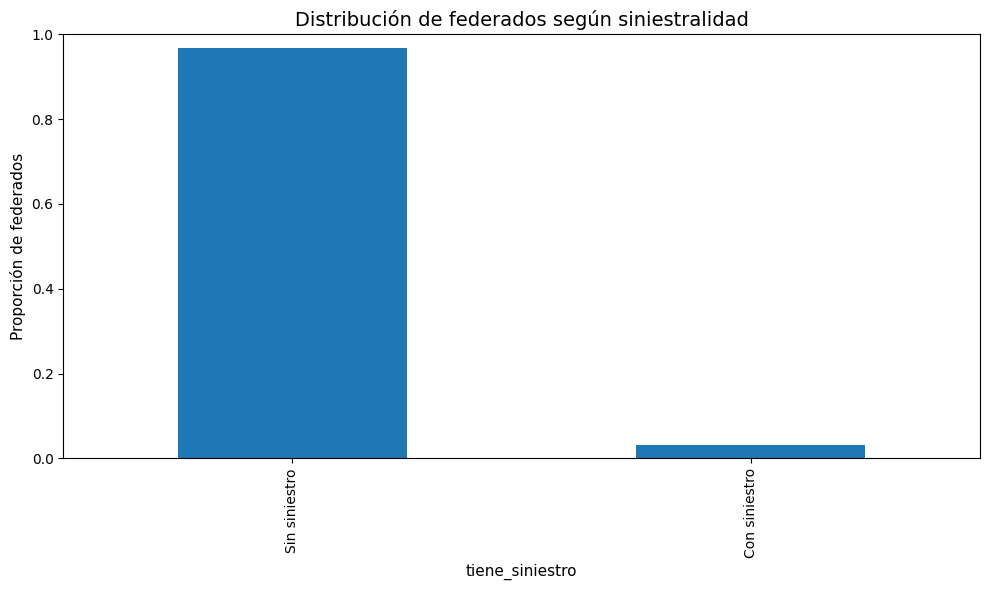

In [62]:
# Visión global: federados con vs sin siniestro

global_comp = (
    federados_modelo["tiene_siniestro"]
    .value_counts(normalize=True)
    .rename(index={True: "Con siniestro", False: "Sin siniestro"})
)

global_comp.plot(kind="bar")
plt.ylabel("Proporción de federados")
plt.title("Distribución de federados según siniestralidad")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()



/var/folders/b6/q04v2jps6dzdnz8xpc7p0q5h0000gn/T/ipykernel_63790/1311057108.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("tramo_edad")["tiene_siniestro"]


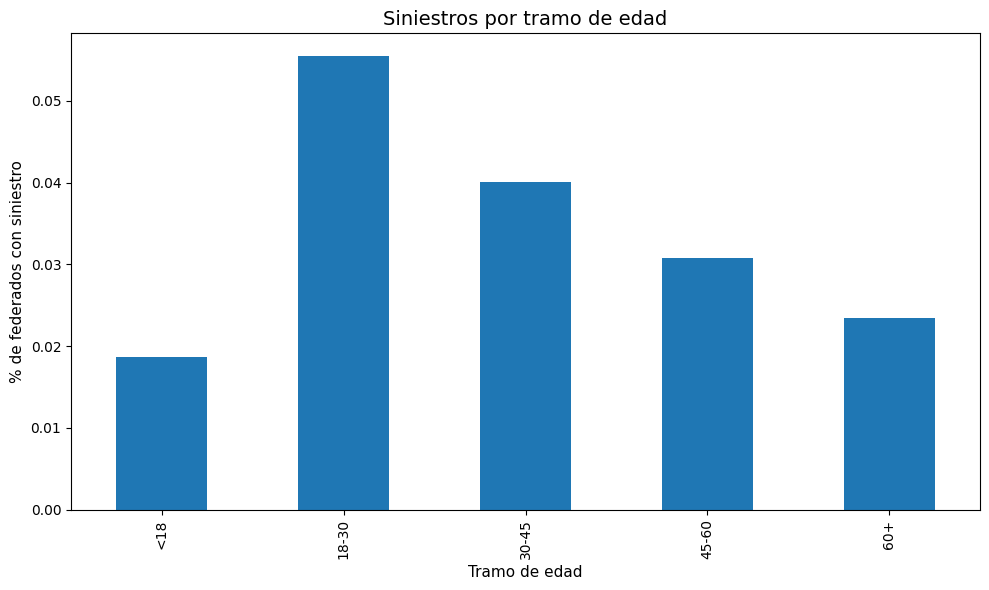

In [63]:
# Probabilidad de siniestro por edad

edad_comp = (
    federados_modelo
    .groupby("tramo_edad")["tiene_siniestro"]
    .mean()
)

edad_comp.plot(kind="bar")
plt.ylabel("% de federados con siniestro")
plt.xlabel("Tramo de edad")
plt.title("Siniestros por tramo de edad")
plt.tight_layout()
plt.show()


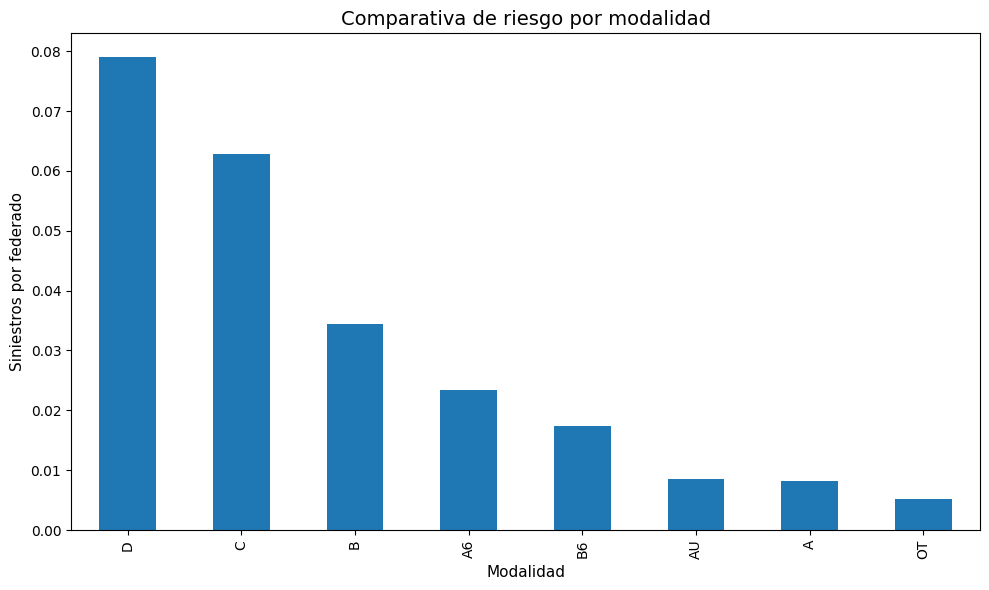

In [13]:
# Riesgo relativo por modalidad

modalidad_comp = (
    federados_modelo
    .groupby("modalidad")
    .agg(
        federados=("nif", "count"),
        siniestros=("num_siniestros", "sum")
    )
)

modalidad_comp["ratio_siniestros"] = (
    modalidad_comp["siniestros"] / modalidad_comp["federados"]
)

modalidad_comp = modalidad_comp.sort_values(
    "ratio_siniestros", ascending=False
).head(8)

modalidad_comp["ratio_siniestros"].plot(kind="bar")
plt.ylabel("Siniestros por federado")
plt.xlabel("Modalidad")
plt.title("Comparativa de riesgo por modalidad")
plt.tight_layout()
plt.show()


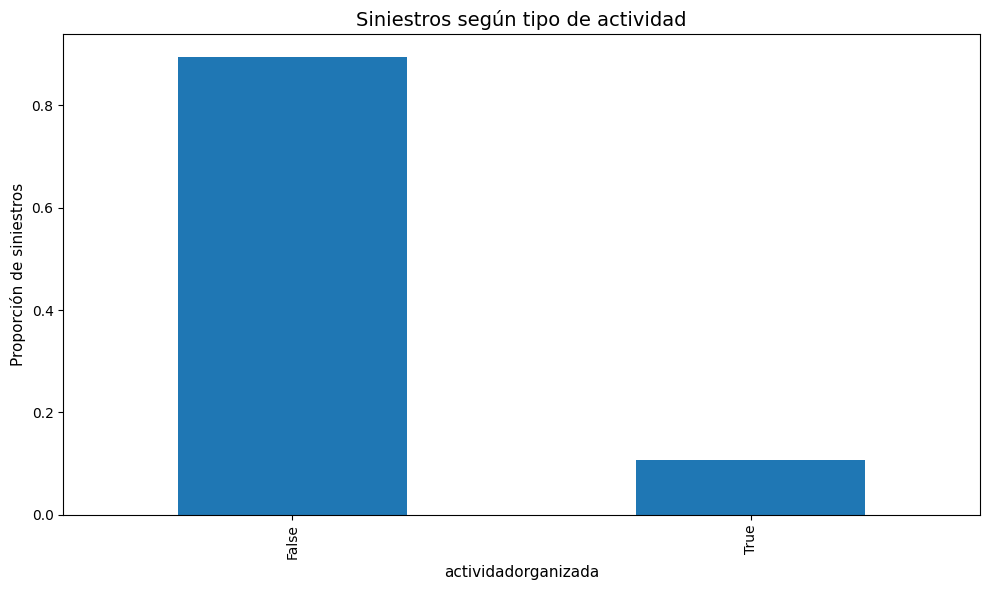

In [64]:
# Actividad organizada vs personal

actividad_comp = (
    siniestros_modelo["actividadorganizada"]
    .value_counts(normalize=True)
    .rename(index={"Sí": "Organizada", "No": "Personal"})
)

actividad_comp.plot(kind="bar")
plt.ylabel("Proporción de siniestros")
plt.title("Siniestros según tipo de actividad")
plt.tight_layout()
plt.show()


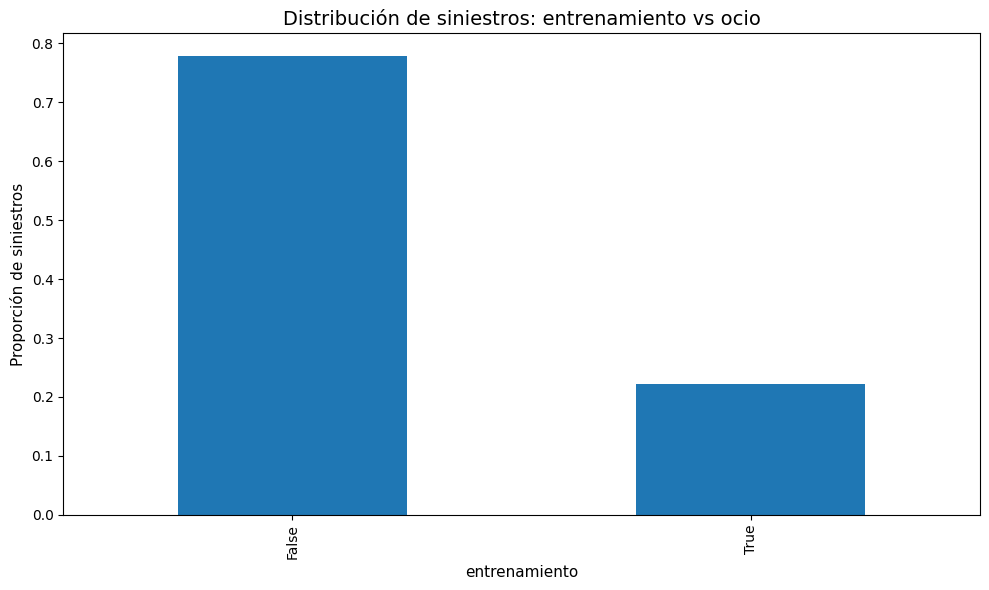

In [15]:
entrenamiento_comp = (
    siniestros_modelo["entrenamiento"]
    .value_counts(normalize=True)
    .rename(index={"Sí": "Entrenamiento", "No": "Ocio"})
)

entrenamiento_comp.plot(kind="bar")
plt.ylabel("Proporción de siniestros")
plt.title("Distribución de siniestros: entrenamiento vs ocio")
plt.tight_layout()
plt.show()


In [ ]:
# Cálculo de la tasa de siniestralidad

num_siniestros = siniestros_modelo.shape[0]
num_federados = federados_modelo["nif"].nunique()

tasa_siniestralidad = (num_siniestros / num_federados) * 1000

tasa_siniestralidad


33.36153114095379

In [20]:
cuadro_global = pd.DataFrame({
    "Indicador": [
        "Número de federados",
        "Número de siniestros",
        "Tasa de siniestralidad (por 1.000)"
    ],
    "Valor": [
        num_federados,
        num_siniestros,
        round(tasa_siniestralidad, 2)
    ]
})

cuadro_global


,Indicador,Valor
0,Número de federados,18914.00
1,Número de siniestros,631.00
2,Tasa de siniestralidad (por 1.000),33.36


In [21]:
tasa_modalidad = (
    federados_modelo
    .groupby("modalidad")
    .agg(
        federados=("nif", "count"),
        siniestros=("num_siniestros", "sum")
    )
)

tasa_modalidad["tasa_x_1000"] = (
    tasa_modalidad["siniestros"] / tasa_modalidad["federados"] * 1000
)

tasa_modalidad = tasa_modalidad.sort_values(
    "tasa_x_1000", ascending=False
)

tasa_modalidad.head()


,federados,siniestros,tasa_x_1000
modalidad,,,
D,329,26.0,79.027356
C,1513,95.0,62.789161
B,13992,481.0,34.376787
A6,128,3.0,23.437500
B6,230,4.0,17.391304


In [22]:
tasa_edad = (
    federados_modelo
    .groupby("tramo_edad")
    .agg(
        federados=("nif", "count"),
        siniestros=("num_siniestros", "sum")
    )
)

tasa_edad["tasa_x_1000"] = (
    tasa_edad["siniestros"] / tasa_edad["federados"] * 1000
)

tasa_edad


/var/folders/b6/q04v2jps6dzdnz8xpc7p0q5h0000gn/T/ipykernel_63790/1725275377.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("tramo_edad")


,federados,siniestros,tasa_x_1000
tramo_edad,,,
<18,1018,20.0,19.646365
18-30,1009,59.0,58.473736
30-45,4072,178.0,43.713163
45-60,6876,225.0,32.722513
60+,5940,149.0,25.084175


In [23]:
cuadro_modalidad = (
    tasa_modalidad
    .reset_index()
    .rename(columns={
        "modalidad": "Modalidad",
        "federados": "Nº federados",
        "siniestros": "Nº siniestros",
        "tasa_x_1000": "Tasa por 1.000 federados"
    })
)

cuadro_modalidad["Tasa por 1.000 federados"] = (
    cuadro_modalidad["Tasa por 1.000 federados"].round(2)
)

cuadro_modalidad.head(10)


,Modalidad,Nº federados,Nº siniestros,Tasa por 1.000 federados
0,D,329,26.0,79.03
1,C,1513,95.0,62.79
2,B,13992,481.0,34.38
3,A6,128,3.0,23.44
4,B6,230,4.0,17.39
5,AU,581,5.0,8.61
6,A,1939,16.0,8.25
7,OT,191,1.0,5.24
8,D Comp.,3,0.0,0.00
9,E,6,0.0,0.00


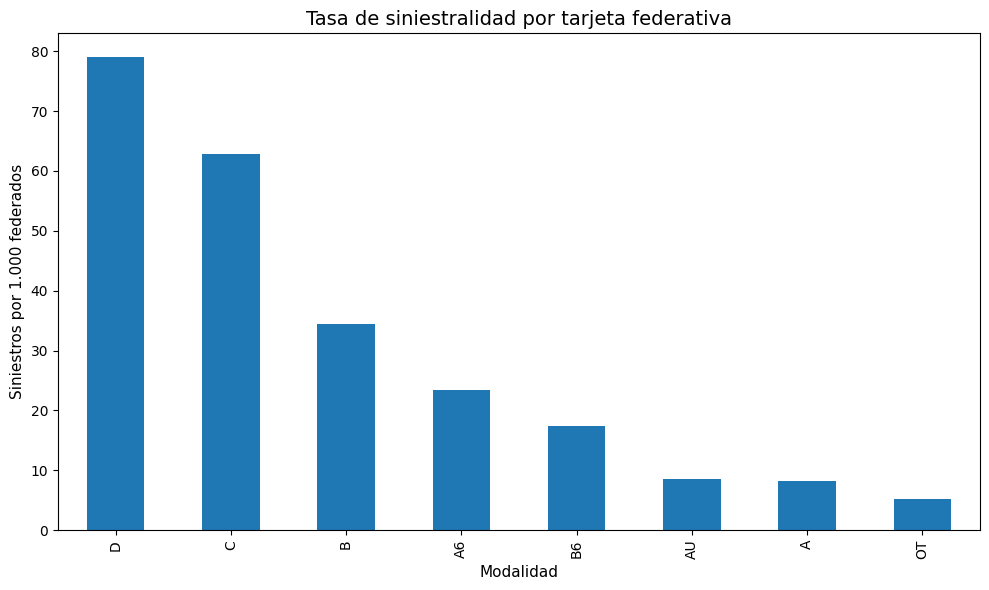

In [26]:
cuadro_modalidad.set_index("Modalidad")["Tasa por 1.000 federados"].head(8).plot(
    kind="bar"
)

plt.ylabel("Siniestros por 1.000 federados")
plt.title("Tasa de siniestralidad por tarjeta federativa")
plt.tight_layout()
plt.show()


In [32]:
dist_modalidad = (
    federados_modelo["modalidad"]
    .value_counts()
)


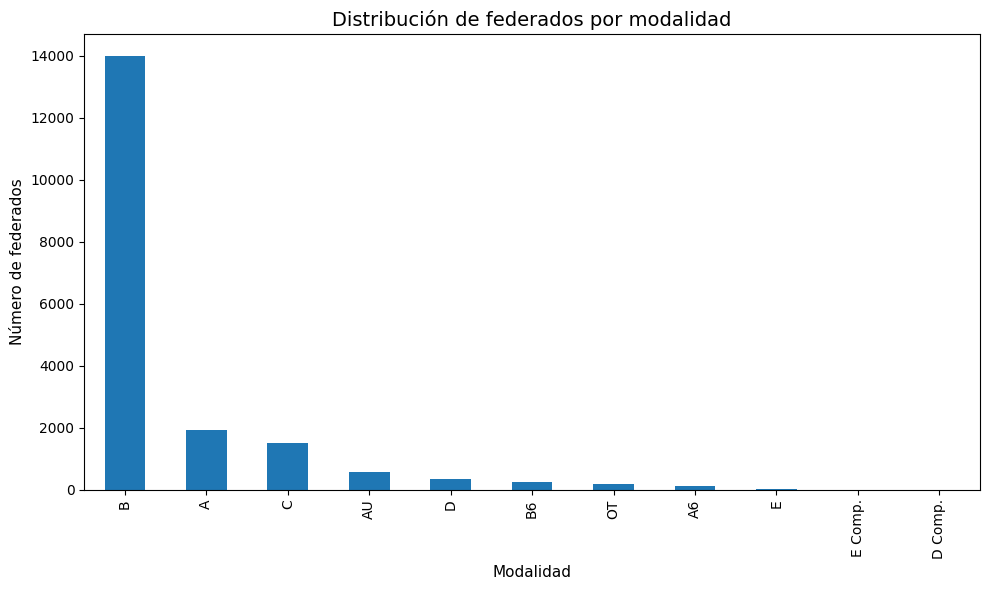

In [33]:
dist_modalidad.plot(kind="bar")
plt.ylabel("Número de federados")
plt.xlabel("Modalidad")
plt.title("Distribución de federados por modalidad")
plt.tight_layout()
plt.show()


In [34]:
dist_modalidad_pct = (
    federados_modelo["modalidad"]
    .value_counts(normalize=True) * 100
)


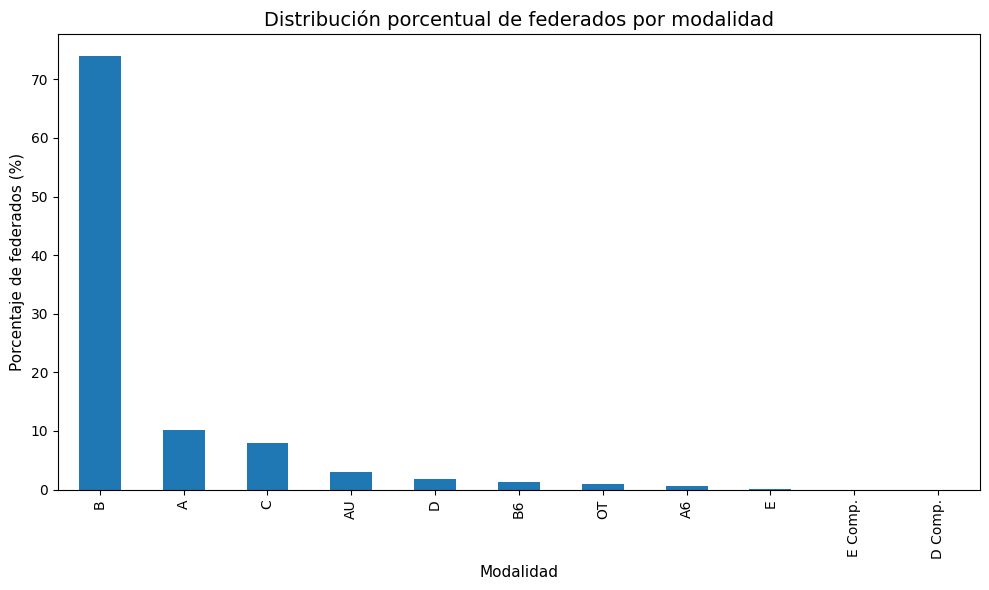

In [35]:
dist_modalidad_pct.plot(kind="bar")
plt.ylabel("Porcentaje de federados (%)")
plt.xlabel("Modalidad")
plt.title("Distribución porcentual de federados por modalidad")
plt.tight_layout()
plt.show()


In [36]:
cuadro_modalidad_dist = pd.DataFrame({
    "Modalidad": dist_modalidad.index,
    "Nº federados": dist_modalidad.values,
    "Porcentaje (%)": dist_modalidad_pct.round(2).values
})

cuadro_modalidad_dist


,Modalidad,Nº federados,Porcentaje (%)
0,B,13992,73.97
1,A,1939,10.25
2,C,1513,8.00
3,AU,581,3.07
4,D,329,1.74
5,B6,230,1.22
6,OT,191,1.01
7,A6,128,0.68
8,E,6,0.03
9,E Comp.,3,0.02


In [37]:
cuadro_modalidad_completo = (
    federados_modelo
    .groupby("modalidad")
    .agg(
        federados=("nif", "count"),
        siniestros=("num_siniestros", "sum")
    )
)

cuadro_modalidad_completo["tasa_x_1000"] = (
    cuadro_modalidad_completo["siniestros"] /
    cuadro_modalidad_completo["federados"] * 1000
)

cuadro_modalidad_completo = cuadro_modalidad_completo.reset_index()
cuadro_modalidad_completo


,modalidad,federados,siniestros,tasa_x_1000
0,A,1939,16.0,8.251676
1,A6,128,3.0,23.437500
2,AU,581,5.0,8.605852
3,B,13992,481.0,34.376787
4,B6,230,4.0,17.391304
5,C,1513,95.0,62.789161
6,D,329,26.0,79.027356
7,D Comp.,3,0.0,0.000000
8,E,6,0.0,0.000000
9,E Comp.,3,0.0,0.000000


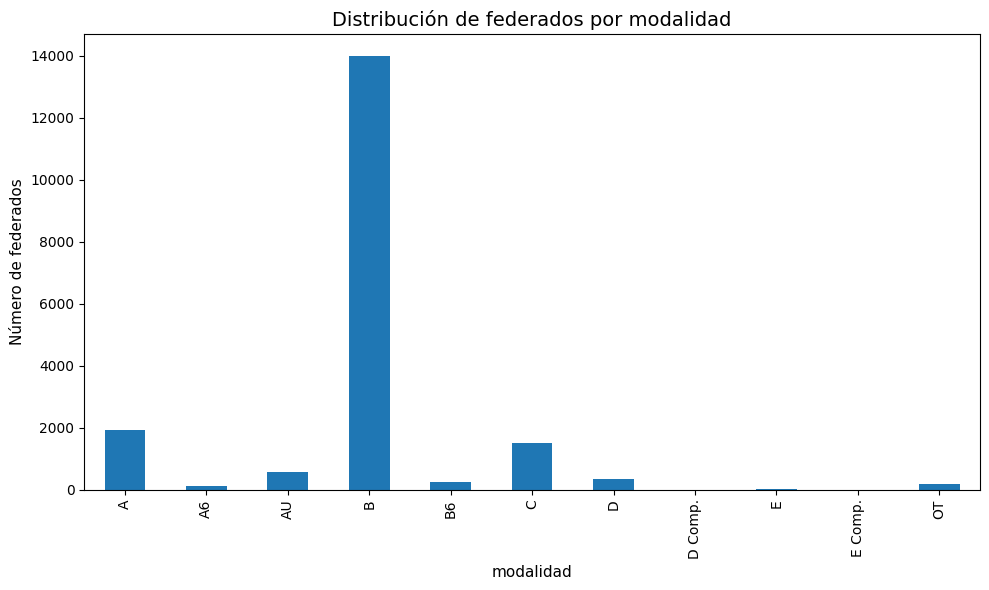

In [38]:
cuadro_modalidad_completo.set_index("modalidad")["federados"].plot(
    kind="bar"
)
plt.ylabel("Número de federados")
plt.title("Distribución de federados por modalidad")
plt.tight_layout()
plt.show()


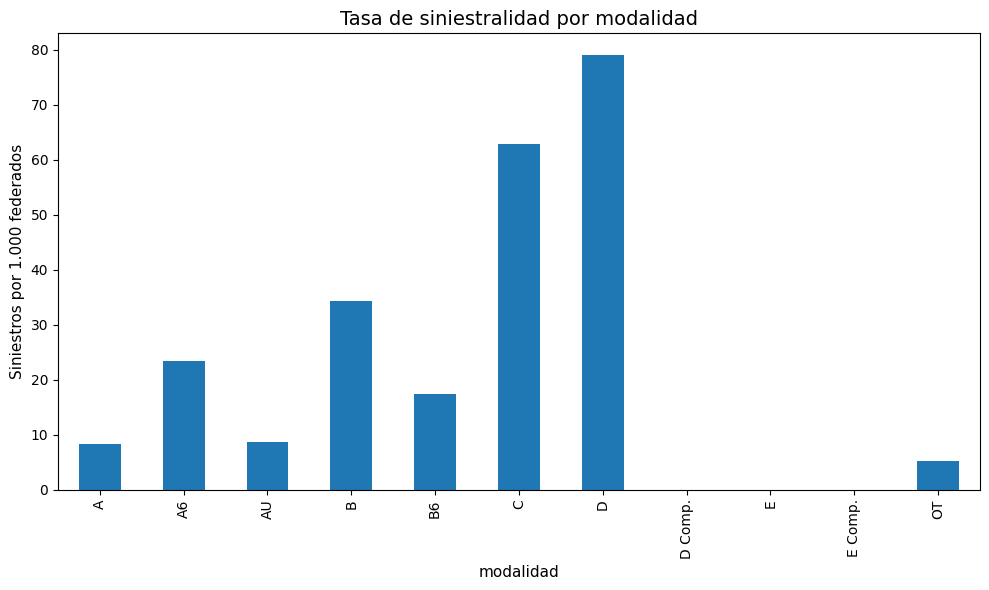

In [39]:
cuadro_modalidad_completo.set_index("modalidad")["tasa_x_1000"].plot(
    kind="bar"
)
plt.ylabel("Siniestros por 1.000 federados")
plt.title("Tasa de siniestralidad por modalidad")
plt.tight_layout()
plt.show()


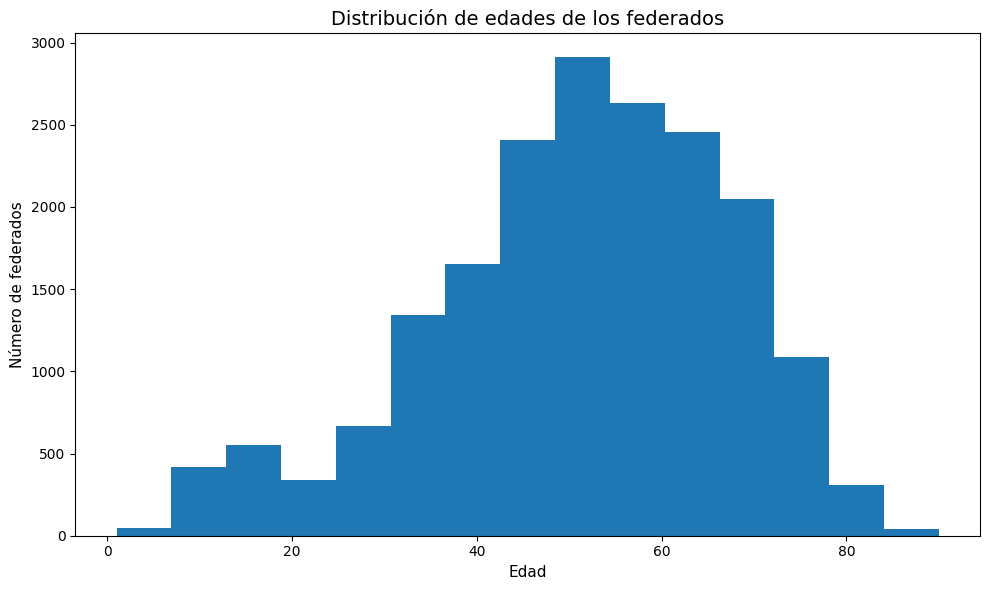

In [40]:
plt.figure(figsize=(10, 6))

plt.hist(
    federados_modelo["edad"],
    bins=15
)

plt.xlabel("Edad")
plt.ylabel("Número de federados")
plt.title("Distribución de edades de los federados")
plt.tight_layout()
plt.show()


In [54]:
siniestros_por_tramo = (
    federados_modelo
    .groupby("tramo_edad", observed=True)["nif"]
    .count()
    .sort_values(ascending=False)
)

siniestros_por_tramo

tramo_edad
45-60    6874
60+      5944
30-45    4070
<18      1018
18-30    1009
Name: nif, dtype: int64